In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Ellipse
from matplotlib.collections import PatchCollection
from matplotlib.markers import MarkerStyle
from matplotlib.path import Path
import btrack, numpy as np, pandas as pd
from btrack.constants import BayesianUpdates
from scipy.stats import zscore
from scipy.signal import savgol_filter

from scipy.stats import binned_statistic_2d
from scipy.signal import savgol_filter

import anndata as an
import scanpy as sc
from collections import Counter
from matplotlib.patches import Patch
import warnings

# tracking algs
import trackpy as tp

Notebook to predict cell cycle phases for individual cells from FUCCI time-series imaging data
* 4 conditions (N wells/replicates): Control (3), mmMYOD1 (2), siPRRX1 (2), HYB (3)

# Load in data

In [2]:
%%time
dpath = "/scratch/indikar_root/indikar1/shared_data/hybrid_imaging/regionprops/"
file_list = glob.glob(f"{dpath}*_*_*.csv") # exclude the test image

df_list = []

for fpath in file_list:
    basename = os.path.basename(fpath).replace(".csv", "")
    stage, condition, scene, _ = basename.split("_")
    
    df = pd.read_csv(fpath)
    df['basename'] = basename
    df['stage'] = int(stage)
    df['condition'] = condition
    df['scene'] = scene
    
    print(f"\t{basename} {df.shape=}")

    df_list.append(df)


df = pd.concat(df_list)
print(f"{df.shape=}")

df['cell_id'] = df['basename'] + "_label" + df['label'].astype(str)

# shift stage 2 times to follow after stage 1
max_time_stage1 = df.loc[df["stage"] == 1, "time"].max()
df["time_shifted"] = df["time"] + (
    (df["stage"] == 2) * (max_time_stage1 + 1)
)

df.head()

	02_siPRRX1_B3_props df.shape=(188240, 49)
	01_mmMYOD1_D4_props df.shape=(35964, 49)
	01_control_D2_props df.shape=(31271, 49)
	01_hybrid_C3_props df.shape=(49123, 49)
	01_mmMYOD1_D3_props df.shape=(33663, 49)
	02_hybrid_C6_props df.shape=(123894, 49)
	02_hybrid_C4_props df.shape=(145648, 49)
	01_hybrid_C4_props df.shape=(64240, 49)
	02_mmMYOD1_D4_props df.shape=(72217, 49)
	02_siPRRX1_B4_props df.shape=(198826, 49)
	02_hybrid_C3_props df.shape=(133759, 49)
	01_hybrid_C6_props df.shape=(57297, 49)
	01_control_C2_props df.shape=(39967, 49)
	02_mmMYOD1_D3_props df.shape=(68484, 49)
	01_siPRRX1_B4_props df.shape=(80394, 49)
	02_control_C2_props df.shape=(94187, 49)
	01_siPRRX1_B3_props df.shape=(70595, 49)
	01_control_B2_props df.shape=(40213, 49)
	02_control_D2_props df.shape=(65965, 49)
	02_control_B2_props df.shape=(91039, 49)
df.shape=(1684986, 49)
CPU times: user 14.4 s, sys: 1.53 s, total: 16 s
Wall time: 17.2 s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,mKate_sum,time,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted
0,1,139.0,770,366,786,378,192.0,777.402878,371.733813,0.787459,...,29.239852,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label1,67
1,2,92.0,513,2953,524,2964,121.0,517.945652,2957.891304,0.204520,...,11.038021,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label2,67
2,3,131.0,2553,722,2566,735,169.0,2558.908397,727.664122,0.528127,...,16.582590,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label3,67
3,4,638.0,2205,1117,2234,1148,899.0,2219.070533,1131.733542,0.746750,...,135.223725,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label4,67
4,5,146.0,702,806,719,818,204.0,710.260274,811.657534,0.793181,...,30.855447,0,2,Cy5,02_siPRRX1_B3_props,2,siPRRX1,B3,02_siPRRX1_B3_props_label5,67


In [18]:
df.columns

Index(['label', 'area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'bbox_area',
       'centroid-0', 'centroid-1', 'eccentricity', 'equivalent_diameter',
       'euler_number', 'extent', 'feret_diameter_max', 'filled_area',
       'inertia_tensor_eigvals-0', 'inertia_tensor_eigvals-1',
       'local_centroid-0', 'local_centroid-1', 'major_axis_length',
       'minor_axis_length', 'orientation', 'perimeter', 'perimeter_crofton',
       'solidity', 'Cy5_mean', 'Cy5_max', 'Cy5_min', 'centroid_x_px',
       'centroid_y_px', 'centroid_x_um', 'centroid_y_um', 'centroid_unit',
       'Cy5_sum', 'TaGFP_mean', 'TaGFP_max', 'TaGFP_min', 'TaGFP_sum',
       'mKate_mean', 'mKate_max', 'mKate_min', 'mKate_sum', 'time',
       'seg_channel_idx', 'seg_channel_name', 'basename', 'stage', 'condition',
       'scene', 'cell_id', 'time_shifted'],
      dtype='object')

In [20]:
print(df['centroid-1'].max())
print(df['centroid_y_px'].max())
print(df['centroid_y_um'].max())

3031.769230769231
2619.694117647058
49392.98388461539


# Track cells

In [3]:
%%time
### --- Tracking by stage ---
# Rename columns for trackpy
pdf = df.rename(columns={
    "time": "frame",
    "centroid_x_px": "x",
    "centroid_y_px": "y"
}).copy()

# Store all per-(cond,scene,stage) tracking results in a list
all_track_dfs = []

for (cond, scene, stage), g in pdf.groupby(["condition", "scene", "stage"]):
    print(f"Tracking: {(cond, scene, stage)}")
    g_sorted = g.sort_values("frame")
    
    # Run tracking
    linked = tp.link_df(
        g_sorted,
        search_range=55,        # adjust as needed
        memory=5,
        adaptive_stop=True
    )
    
    # Add context columns
    linked["condition"] = cond
    linked["scene"] = scene
    linked["stage"] = stage
    
    # Optionally filter out short tracks (e.g., less than 50 frames)
    linked = tp.filter_stubs(linked, threshold=10)
    
    print(f"\tlinked.shape: {linked.shape}")
    
    all_track_dfs.append(linked)

# Combine all per-stage results
all_traj = pd.concat(all_track_dfs, ignore_index=True)
print(f"All tracked data shape: {all_traj.shape}")

all_traj['particle_id'] = all_traj['stage'].astype(str) + '_' + all_traj['condition'] + '_' + all_traj['scene'] + '_' + all_traj['particle'].astype(str)
all_traj.head()

Frame 136: 1690 trajectories present.
	linked.shape: (194021, 52)
All tracked data shape: (1633220, 52)
CPU times: user 58.7 s, sys: 4.24 s, total: 1min 2s
Wall time: 1min 8s


,label,area,bbox-0,bbox-1,bbox-2,bbox-3,bbox_area,centroid-0,centroid-1,eccentricity,...,seg_channel_idx,seg_channel_name,basename,stage,condition,scene,cell_id,time_shifted,particle,particle_id
0,398,136.0,152,26,162,42,160.0,156.867647,33.529412,0.790996,...,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label398,0,0,1_control_B2_0
1,400,107.0,2571,229,2588,237,136.0,2579.112150,232.588785,0.891693,...,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label400,0,2,1_control_B2_2
2,385,118.0,545,609,558,624,195.0,551.245763,616.525424,0.891239,...,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label385,0,3,1_control_B2_3
3,386,157.0,2505,1684,2516,1704,220.0,2509.847134,1693.929936,0.880899,...,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label386,0,4,1_control_B2_4
4,387,86.0,2223,2238,2235,2249,132.0,2229.174419,2243.581395,0.734465,...,2,Cy5,01_control_B2_props,1,control,B2,01_control_B2_props_label387,0,5,1_control_B2_5


In [4]:
all_traj.columns

Index(['label', 'area', 'bbox-0', 'bbox-1', 'bbox-2', 'bbox-3', 'bbox_area',
       'centroid-0', 'centroid-1', 'eccentricity', 'equivalent_diameter',
       'euler_number', 'extent', 'feret_diameter_max', 'filled_area',
       'inertia_tensor_eigvals-0', 'inertia_tensor_eigvals-1',
       'local_centroid-0', 'local_centroid-1', 'major_axis_length',
       'minor_axis_length', 'orientation', 'perimeter', 'perimeter_crofton',
       'solidity', 'Cy5_mean', 'Cy5_max', 'Cy5_min', 'x', 'y', 'centroid_x_um',
       'centroid_y_um', 'centroid_unit', 'Cy5_sum', 'TaGFP_mean', 'TaGFP_max',
       'TaGFP_min', 'TaGFP_sum', 'mKate_mean', 'mKate_max', 'mKate_min',
       'mKate_sum', 'frame', 'seg_channel_idx', 'seg_channel_name', 'basename',
       'stage', 'condition', 'scene', 'cell_id', 'time_shifted', 'particle',
       'particle_id'],
      dtype='object')

# Filter tracks

In [5]:
columns_to_keep = [
    'condition', 'scene', 'stage', 'particle', 'particle_id', 'frame', 'time_shifted',
    'filled_area', 'Cy5_mean', 'TaGFP_mean', 'mKate_mean', 'x', 'y',
]

tdf = all_traj[columns_to_keep].copy()

# calculate total trajectory length per cell
tdf['path_length'] = tdf.groupby('particle_id')['frame'].transform(lambda x: x.nunique())

print(tdf.shape)
tdf.head()

(1633220, 14)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67
1,control,B2,1,2,1_control_B2_2,0,0,107.0,0.094927,0.234181,0.180446,232.588785,2579.112150,61
2,control,B2,1,3,1_control_B2_3,0,0,118.0,0.037478,0.136275,0.193143,616.525424,551.245763,11
3,control,B2,1,4,1_control_B2_4,0,0,157.0,0.040521,0.247596,0.201448,1693.929936,2509.847134,42
4,control,B2,1,5,1_control_B2_5,0,0,86.0,0.107119,0.047916,0.010504,2243.581395,2229.174419,67


In [6]:
print(f"N cells: {tdf['particle_id'].nunique()}")

# 1. Filter out short trajectories
min_path_length = 50
tdf = tdf[tdf["path_length"] >= min_path_length]
print(f"N cells with at least 50 frames: {tdf['particle_id'].nunique()}\n")

# 2. Sort chronologically per cell to find frame steps
tdf = tdf.sort_values(["particle_id", "frame"])
frame_diff = tdf.groupby("particle_id")["frame"].diff()

# 3. Compute missing frames per step (continuous tracking step = 1 frame, or 0 gap)
tdf["gap_length"] = (frame_diff - 1).clip(lower=0).fillna(0)

# 4. Extract global gap profile metrics per unique cell
gap_info = (
    tdf.groupby("particle_id")["gap_length"]
    .agg(
        has_gap=lambda x: x.gt(0).any(),
        max_gap_length="max",
    )
    .reset_index()
)

# 5. Merge metrics back and remove raw step metrics
tdf = tdf.merge(gap_info, on="particle_id").drop(columns=["gap_length"])

# 6. Display quality metrics and distribution summaries
print("--- Gap Prevalence ---")
print(f"{tdf.drop_duplicates('particle_id')['has_gap'].value_counts()}\n")

print("--- Max Gap Distribution by Condition ---")
unique_cells = tdf.drop_duplicates("particle_id")
print(unique_cells.groupby("condition")["max_gap_length"].describe())


print(f"\nN cells: {tdf['particle_id'].nunique()}")
print(tdf.shape)
tdf.head()

N cells: 27824
N cells with at least 50 frames: 15068

--- Gap Prevalence ---
has_gap
False    8941
True     6127
Name: count, dtype: int64

--- Max Gap Distribution by Condition ---
            count      mean       std  min  25%  50%  75%  max
condition                                                     
control    3366.0  0.624777  1.321116  0.0  0.0  0.0  0.0  5.0
hybrid     4908.0  1.305420  1.655664  0.0  0.0  0.0  2.0  5.0
mmMYOD1    1957.0  0.761369  1.405794  0.0  0.0  0.0  1.0  5.0
siPRRX1    4837.0  1.330784  1.703688  0.0  0.0  0.0  3.0  5.0

N cells: 15068
(1300948, 16)


,condition,scene,stage,particle,particle_id,frame,time_shifted,filled_area,Cy5_mean,TaGFP_mean,mKate_mean,x,y,path_length,has_gap,max_gap_length
0,control,B2,1,0,1_control_B2_0,0,0,136.0,0.061765,0.408809,0.206251,33.529412,156.867647,67,False,0.0
1,control,B2,1,0,1_control_B2_0,1,1,143.0,0.149553,0.394926,0.205844,32.937063,157.265734,67,False,0.0
2,control,B2,1,0,1_control_B2_0,2,2,153.0,0.252953,0.375882,0.202407,34.091503,159.078431,67,False,0.0
3,control,B2,1,0,1_control_B2_0,3,3,156.0,0.374112,0.369431,0.197891,33.737179,160.628205,67,False,0.0
4,control,B2,1,0,1_control_B2_0,4,4,158.0,0.486338,0.368193,0.197863,34.177215,161.974684,67,False,0.0


In [7]:
# 1. Filter out trajectories with gaps strictly greater than 1 frame
tdf = tdf[tdf["max_gap_length"] <= 1].copy()
print(f"N cells with max 1 frame gap: {tdf['particle_id'].nunique()}")

# 2. Insert missing rows for the 1-frame gaps
# We group by cell and reindex each from its specific start to end frame
tdf = tdf.sort_values(["particle_id", "frame"])
tdf = (
    tdf.groupby("particle_id", group_keys=False)
    .apply(
        lambda g: g.set_index("frame")
        .reindex(range(g["frame"].min(), g["frame"].max() + 1))
        .rename_axis("frame")
        .reset_index()
    )
    .reset_index(drop=True)
)

# 3. Create tracking columns BEFORE interpolating
# If 'particle_id' is NaN, it means this row was just generated as a gap
tdf["is_interp"] = tdf["particle_id"].isna()

tdf["particle_id"] = tdf.groupby(tdf["particle_id"].bfill())[
    "particle_id"
].transform(lambda x: x.bfill().ffill())

# 4. Linearly interpolate tracking coordinates and intensity measurements
numeric_cols = [
    "x",
    "y",
    "Cy5_mean",
    "TaGFP_mean",
    "mKate_mean",
    "filled_area",
    "time_shifted",
]

tdf[numeric_cols] = tdf.groupby("particle_id")[numeric_cols].transform(
    lambda x: x.interpolate(method="linear")
)

# 5. Fill structural metadata columns for the newly created gap rows
metadata_cols = [
    "particle_id",
    "condition",
    "scene",
    "stage",
    "particle",
    "has_gap",
    "max_gap_length",
]
tdf[metadata_cols] = tdf.groupby("particle_id")[metadata_cols].bfill().ffill()


# 6. Assess jumps across the gap for error tracking
# Grab the values from 1 frame before and 1 frame after the interpolation points
pre_gap_mkate = tdf["mKate_mean"].shift(1)
post_gap_mkate = tdf["mKate_mean"].shift(-1)
pre_gap_tagfp = tdf["TaGFP_mean"].shift(1)
post_gap_tagfp = tdf["TaGFP_mean"].shift(-1)

# Calculate the jump intensity only on rows that were filled
tdf["mkate_jump"] = np.where(
    tdf["is_interp"], (post_gap_mkate - pre_gap_mkate).abs(), 0
)
tdf["tagfp_jump"] = np.where(
    tdf["is_interp"], (post_gap_tagfp - pre_gap_tagfp).abs(), 0
)

# Broadcast the maximum jump seen anywhere in a track back to all rows of that cell
tdf["max_cell_mkate_jump"] = tdf.groupby("particle_id")[
    "mkate_jump"
].transform("max")
tdf["max_cell_tagfp_jump"] = tdf.groupby("particle_id")[
    "tagfp_jump"
].transform("max")

# 7. Recalculate true path length now that the 1-frame gap rows are populated
tdf["path_length"] = tdf.groupby("particle_id")["frame"].transform("count")

print(tdf.shape)
tdf.head()

N cells with max 1 frame gap: 10689


/tmp/ipykernel_3417603/1186642621.py:10: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_3417603/1186642621.py:52: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tdf[metadata_cols] = tdf.groupby("particle_id")[metadata_cols].bfill().ffill()


(925597, 21)


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,x,y,path_length,has_gap,max_gap_length,is_interp,mkate_jump,tagfp_jump,max_cell_mkate_jump,max_cell_tagfp_jump
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,33.529412,156.867647,67,False,0.0,False,0.0,0.0,0.0,0.0
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,32.937063,157.265734,67,False,0.0,False,0.0,0.0,0.0,0.0
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,34.091503,159.078431,67,False,0.0,False,0.0,0.0,0.0,0.0
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,33.737179,160.628205,67,False,0.0,False,0.0,0.0,0.0,0.0
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,34.177215,161.974684,67,False,0.0,False,0.0,0.0,0.0,0.0


In [24]:
# Check how many rows were added by comparing your new dataframe length to a tracking metric
print(f"Total rows in processed data: {len(tdf)}")
print(f"Sum of original path lengths: {tdf.drop_duplicates('particle_id')['path_length'].sum()}")

# Verify all max gap lengths are now 0 (since they've been filled)
print("\nPost-processing Gap Check (Should all be 0):")
print(tdf.groupby("condition")["max_gap_length"].max())

# Count how many unique cells survived the QC filter
print(f"\nNumber of cells remaining: {tdf['particle_id'].nunique()}")

Total rows in processed data: 925597
Sum of original path lengths: 925597

Post-processing Gap Check (Should all be 0):
condition
control    1.0
hybrid     1.0
mmMYOD1    1.0
siPRRX1    1.0
Name: max_gap_length, dtype: float64

Number of cells remaining: 10689


In [ ]:
# from below testing: 0.01 is fine
# 0.17 is big, so is 0.35

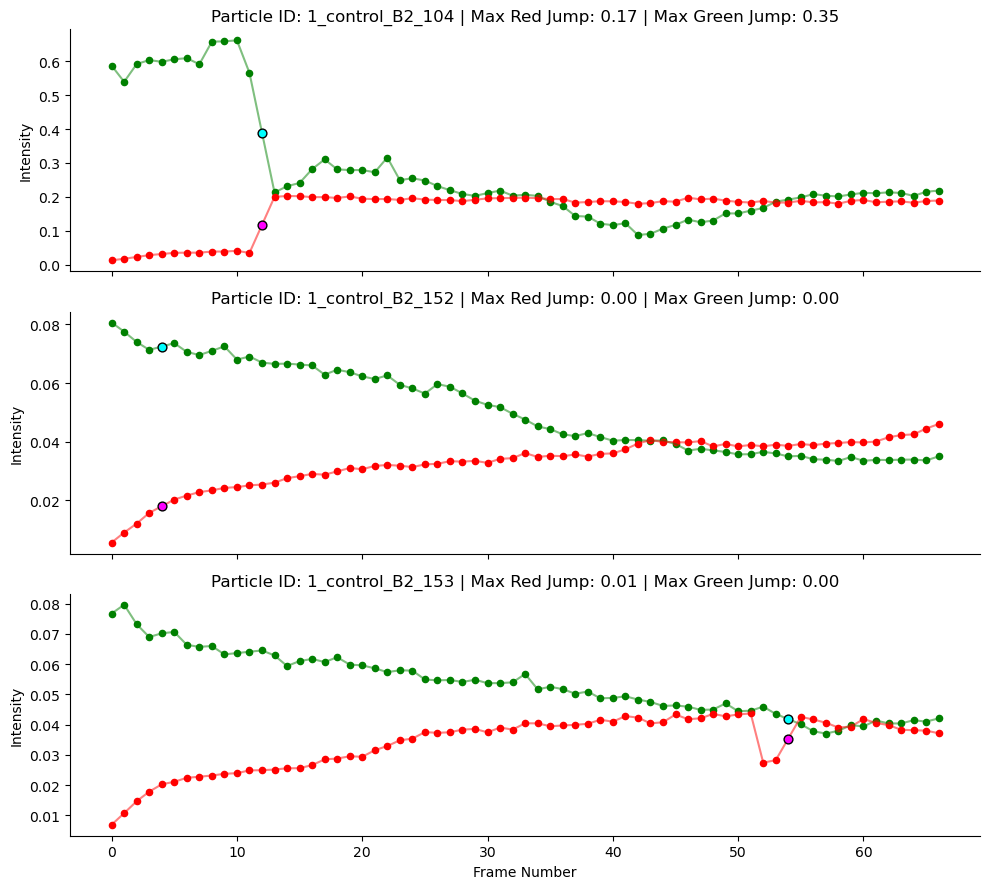

In [8]:
# 1. Grab a few particle IDs that originally had a gap (has_gap was True)
cells_with_gaps = tdf[tdf["has_gap"] == True]["particle_id"].unique()

# Pick up to the first 3 cells to inspect
test_particles = cells_with_gaps[:3]
# test_particles = np.random.choice(cells_with_gaps, 3)

# 2. Plot their reporter trajectories to visually audit the interpolation
fig, axes = plt.subplots(len(test_particles), 1, figsize=(10, 3 * len(test_particles)), sharex=True)
if len(test_particles) == 1: axes = [axes] # Ensure axes is iterable if only 1 cell found

for ax, pid in zip(axes, test_particles):
    cell_df = tdf[tdf["particle_id"] == pid]
    
    # Split into normal data points vs interpolated data points
    normal_pts = cell_df[cell_df["is_interp"] == False]
    interp_pts = cell_df[cell_df["is_interp"] == True]
    
    # Plot the full line (which includes the interpolated step)
    ax.plot(cell_df["frame"], cell_df["TaGFP_mean"], color="g", alpha=0.5, label="Green")
    ax.plot(cell_df["frame"], cell_df["mKate_mean"], color="r", alpha=0.5, label="Red")
    
    # Scatter normal data points
    ax.scatter(normal_pts["frame"], normal_pts["TaGFP_mean"], color="g", s=20)
    ax.scatter(normal_pts["frame"], normal_pts["mKate_mean"], color="r", s=20)
    
    ax.scatter(
        interp_pts["frame"],
        interp_pts["TaGFP_mean"],
        color="cyan",
        edgecolor="k",
        s=40,
        label="Filled Green",
        zorder=5,
    )
    ax.scatter(
        interp_pts["frame"],
        interp_pts["mKate_mean"],
        color="magenta",
        edgecolor="k",
        s=40,
        label="Filled Red",
        zorder=5,
    )
    
    # Show calculated jumps in the title to help guide your future threshold choice
    r_jump = cell_df["max_cell_mkate_jump"].iloc[0]
    g_jump = cell_df["max_cell_tagfp_jump"].iloc[0]
    ax.set_title(
        f"Particle ID: {pid} | Max Red Jump: {r_jump:.2f} | Max Green Jump: {g_jump:.2f}"
    )
    ax.set_ylabel("Intensity")

axes[-1].set_xlabel("Frame Number")
sns.despine()
plt.tight_layout()
plt.show()

In [9]:
t = 0.1 
tdf['is_tracking_error'] = (tdf['max_cell_mkate_jump'] > t) | (tdf['max_cell_tagfp_jump'] > t)

flagged_counts = tdf.drop_duplicates("particle_id")[
    "is_tracking_error"
].value_counts()
print("--- Tracking Error Flag Summary ---")
print(flagged_counts)

--- Tracking Error Flag Summary ---
is_tracking_error
False    10061
True       628
Name: count, dtype: int64


In [10]:
cdf = tdf[tdf['is_tracking_error'] == False].copy()
print(f"Number of cells: {cdf['particle_id'].nunique()}")
print(cdf.shape)
cdf.head()

Number of cells: 10061
(868526, 22)


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,y,path_length,has_gap,max_gap_length,is_interp,mkate_jump,tagfp_jump,max_cell_mkate_jump,max_cell_tagfp_jump,is_tracking_error
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,156.867647,67,False,0.0,False,0.0,0.0,0.0,0.0,False
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,157.265734,67,False,0.0,False,0.0,0.0,0.0,0.0,False
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,159.078431,67,False,0.0,False,0.0,0.0,0.0,0.0,False
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,160.628205,67,False,0.0,False,0.0,0.0,0.0,0.0,False
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,161.974684,67,False,0.0,False,0.0,0.0,0.0,0.0,False


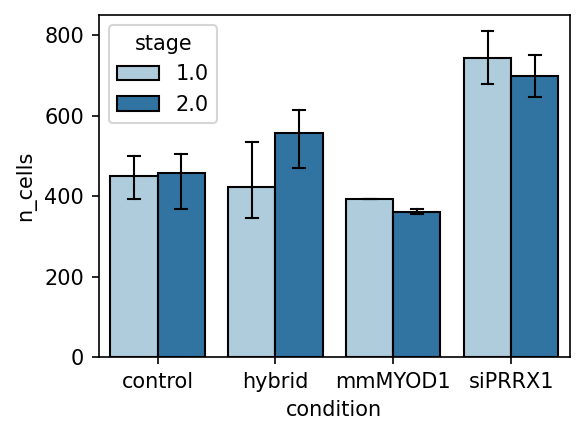

In [11]:
cell_counts = (
    cdf.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(4, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.tight_layout()
plt.show()

In [12]:
### Max distance in a single frame

cdf.head()

,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,y,path_length,has_gap,max_gap_length,is_interp,mkate_jump,tagfp_jump,max_cell_mkate_jump,max_cell_tagfp_jump,is_tracking_error
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,156.867647,67,False,0.0,False,0.0,0.0,0.0,0.0,False
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,157.265734,67,False,0.0,False,0.0,0.0,0.0,0.0,False
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,159.078431,67,False,0.0,False,0.0,0.0,0.0,0.0,False
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,160.628205,67,False,0.0,False,0.0,0.0,0.0,0.0,False
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,161.974684,67,False,0.0,False,0.0,0.0,0.0,0.0,False


In [14]:
cdf1 = cdf.copy()

cdf1 = cdf1.sort_values(by=['particle_id', 'frame']).copy()

# calculate the shift/difference in coordinates within each cell group
grouped = cdf1.groupby('particle_id')
cdf1['dx'] = grouped['x'].diff()
cdf1['dy'] = grouped['y'].diff()

# calculate Euclidean distance (step-by-step displacement)
cdf1['step_distance'] = np.sqrt(cdf1['dx']**2 + cdf1['dy']**2)

steps = cdf1['step_distance'].dropna()
print(steps.describe())

count    858465.000000
mean          4.881660
std           4.459748
min           0.000000
25%           1.767578
50%           3.629884
75%           6.626686
max          54.931493
Name: step_distance, dtype: float64


In [24]:
cdf1['step_distance'].quantile(0.9)

10.421709954374945

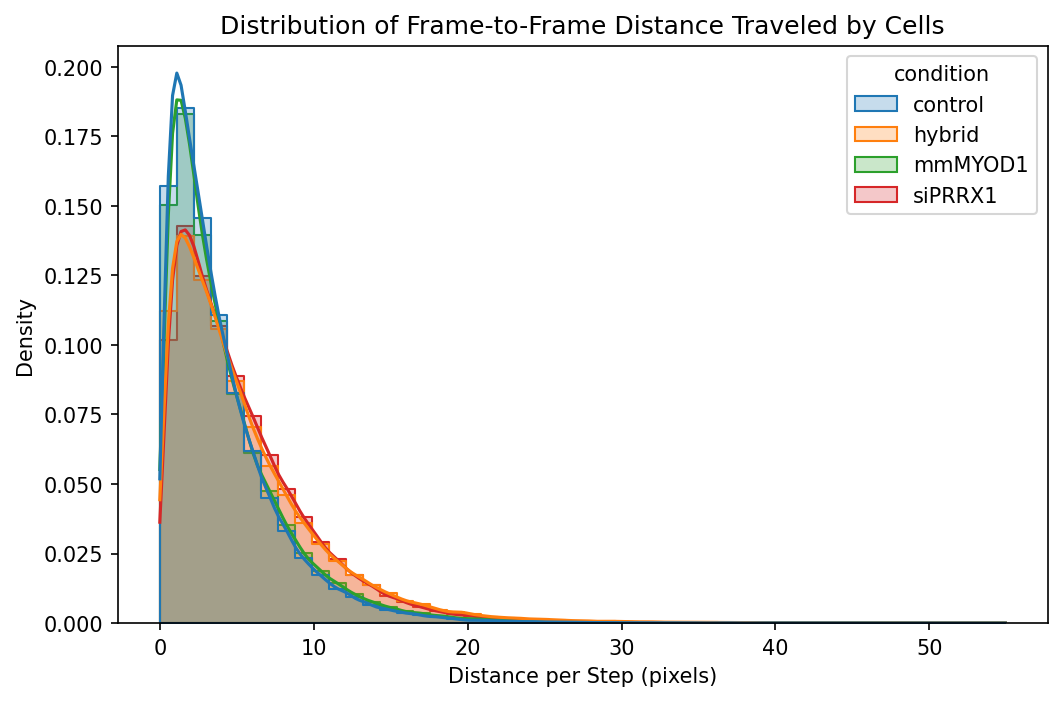

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=cdf1,
    x='step_distance',
    hue='condition',  # Compare your experimental conditions
    kde=True,
    bins=50,
    element='step',
    stat='density',
    common_norm=False
)
plt.title('Distribution of Frame-to-Frame Distance Traveled by Cells')
plt.xlabel('Distance per Step (pixels)')
plt.ylabel('Density')
plt.show()

In [17]:
cell_summaries = cdf1.groupby('particle_id')['step_distance'].agg(['mean', 'median', 'std', 'max'])
cell_summaries.head()

,mean,median,std,max
particle_id,,,,
1_control_B2_0,2.277138,1.839403,1.534808,6.335062
1_control_B2_101,3.294526,1.991213,3.350717,13.115115
1_control_B2_102,4.114267,3.087935,3.216486,10.775346
1_control_B2_103,4.672165,3.741773,3.428016,15.769959
1_control_B2_105,6.865887,6.090425,3.929258,22.328521


# As in PIP-FUCCI paper

In [64]:
cdf.head()

,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,mKate_norm,TaGFP_norm,green_slope,gem_is_rising,is_mitotic_crash,rise_frame_num,crash_frame_num,rise_frame,crash_frame,is_full_cycle
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,1.000000,0.984902,NaN,True,False,0.0,NaN,0.0,3.0,True
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.999014,0.968178,-0.016723,True,False,1.0,NaN,0.0,3.0,True
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.993130,0.947310,-0.020868,True,False,2.0,NaN,0.0,3.0,True
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.979619,0.915687,-0.031623,False,True,NaN,3.0,0.0,3.0,True
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.966721,0.894219,-0.021468,False,False,NaN,NaN,0.0,3.0,True


In [68]:
# 1. Smooth signals per track using a rolling window of 3 (per the paper)
cdf = cdf.sort_values(["particle_id", "frame"])
cdf["mKate_smooth"] = (
    cdf.groupby("particle_id")["mKate_mean"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
cdf["TaGFP_smooth"] = (
    cdf.groupby("particle_id")["TaGFP_mean"]
    .rolling(window=3, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

# 2. Track-specific normalization (scale each cell to its own max)
track_max = cdf.groupby("particle_id")[["mKate_smooth", "TaGFP_smooth"]].transform("max")
cdf["mKate_norm"] = cdf["mKate_smooth"] / track_max["mKate_smooth"]
cdf["TaGFP_norm"] = cdf["TaGFP_smooth"] / track_max["TaGFP_smooth"]

# 3. Track-specific minimums
track_min = cdf.groupby("particle_id")[["TaGFP_smooth"]].transform("min")

# 4. Calculate frame-to-frame slopes (derivatives)
cdf["green_slope"] = cdf.groupby("particle_id")["TaGFP_norm"].diff()
track_max_slope = cdf.groupby("particle_id")["green_slope"].transform("min")  # Most negative slope = steepest drop

# 5. Annotate landmarks based on paper criteria
# Geminin Rise: First point showing 3% increase over track minimum
cdf["gem_is_rising"] = (
    cdf["TaGFP_smooth"] >= track_min["TaGFP_smooth"] + 0.03
)

# Mitotic Crash: Slope is at least 70% as steep as the maximum track drop
cdf["is_mitotic_crash"] = cdf["green_slope"] <= (0.70 * track_max_slope)

# Create temporary columns that hold the frame number ONLY when the condition is True
cdf["rise_frame_num"] = np.where(cdf["gem_is_rising"], cdf["frame"], np.nan)
cdf["crash_frame_num"] = np.where(cdf["is_mitotic_crash"], cdf["frame"], np.nan)

# Aggregate by taking the 'min' (the first frame the event is detected)
cell_cycle_check = (
    cdf.groupby("particle_id")
    .agg(
        rise_frame=("rise_frame_num", "min"),
        crash_frame=("crash_frame_num", "min"),
    )
    .reset_index()
)

# A cell undergoes a full cycle if it has a valid rise frame and a subsequent crash frame
cell_cycle_check["is_full_cycle"] = (
    cell_cycle_check["rise_frame"].notna()
    & cell_cycle_check["crash_frame"].notna()
    & (cell_cycle_check["rise_frame"] < cell_cycle_check["crash_frame"])
)

# Merge back into master dataframe
cdf = cdf.merge(
    cell_cycle_check[["particle_id", "rise_frame", "crash_frame", "is_full_cycle"]],
    on="particle_id",
)
fdf = cdf[cdf["is_full_cycle"] == True].copy()

In [69]:
print(fdf['particle_id'].nunique())

9091


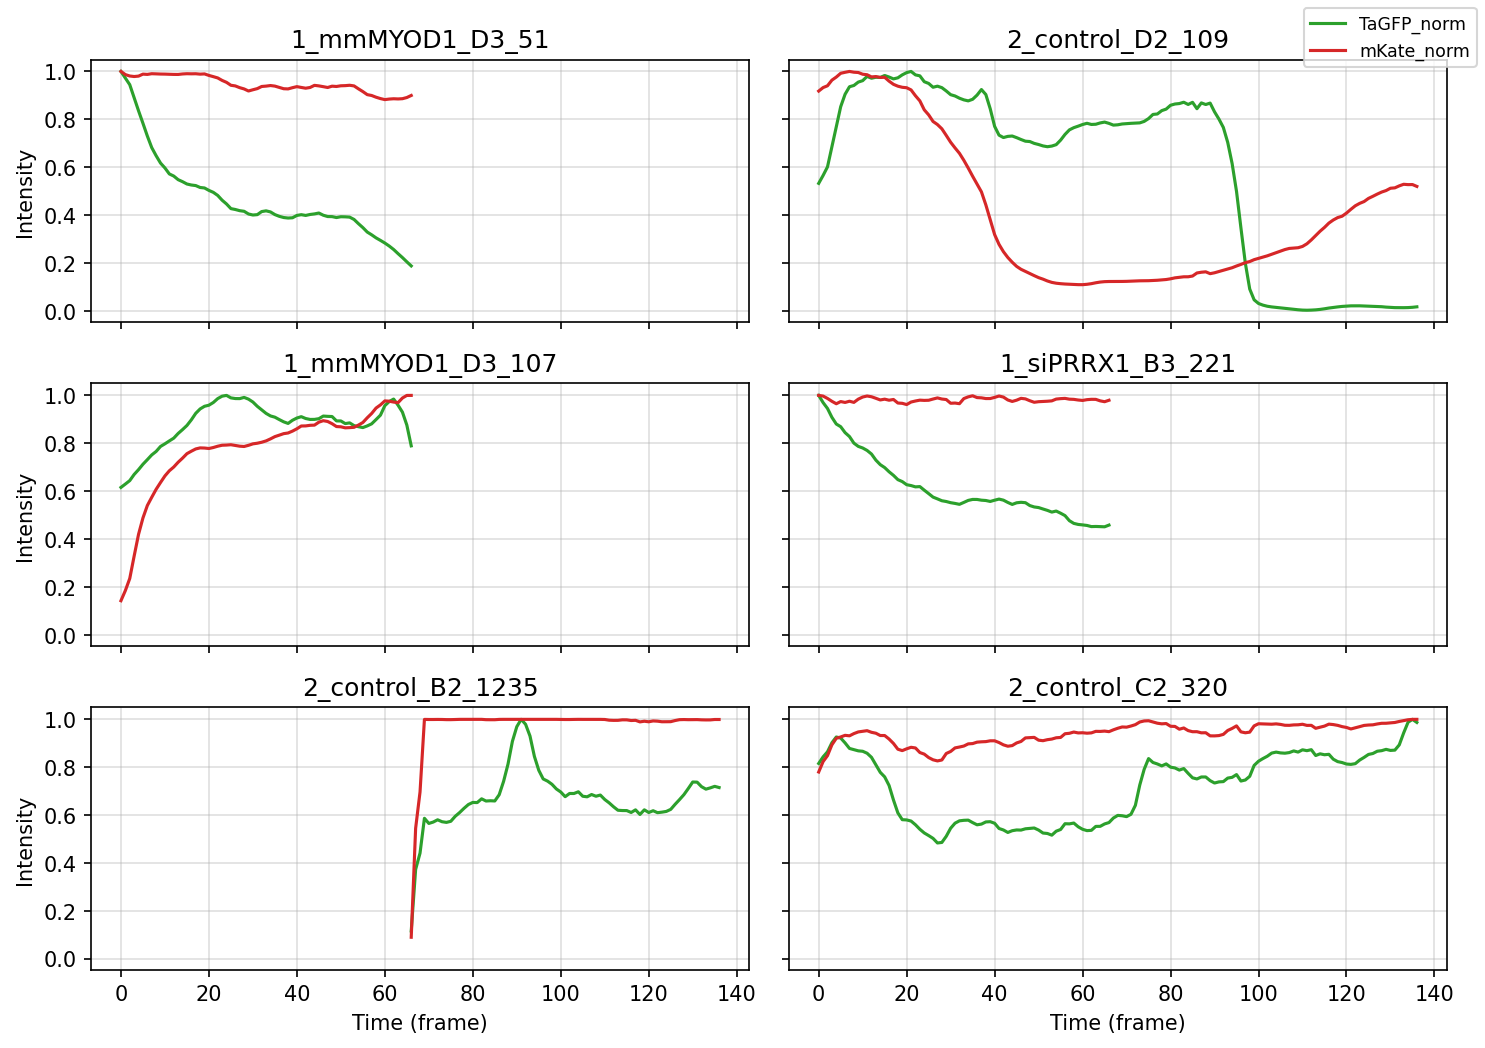

In [50]:
sampled_cells = np.random.choice(fdf['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    tmp = fdf[fdf['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(tmp['frame'], tmp['TaGFP_norm'], label='TaGFP_norm', color='tab:green')
    ax.plot(tmp['frame'], tmp['mKate_norm'], label='mKate_norm', color='tab:red')
    # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

In [57]:
# Initialize all rows as unassigned
fdf["phase"] = "unassigned"

# We use the landmark frames calculated per cell to assign states sequentially
# Frame indexes for these events must be broadcasted or mapped per particle_id

# 1. G1 Phase: From the start of the track up until Geminin begins to rise
fdf["phase"] = np.where(fdf["frame"] < fdf["rise_frame"], "G1", fdf["phase"])

# 2. S Phase: From the moment Geminin rises until PIP hits its baseline 'Mid' point
# (If tracking standard FUCCI, this is where Green rises and Red is crashing)
fdf["phase"] = np.where(
    (fdf["frame"] >= fdf["rise_frame"]) & (fdf["frame"] < fdf["crash_frame"]),
    "S/G2",
    fdf["phase"],
)

# 3. M Phase: The window during the sharpest drop of the Green channel
# This lasts from the start of the steep crash until it hits the minimum baseline
fdf["phase"] = np.where(
    (fdf["frame"] >= fdf["crash_frame"])
    & (fdf["frame"] <= fdf["crash_frame"] + 2),  # M-phase is typically brief (1-2 frames at 20 min intervals)
    "M",
    fdf["phase"],
)

fdf.head()

,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,TaGFP_smooth,mKate_norm,TaGFP_norm,green_slope,gem_is_rising,is_mitotic_crash,is_full_cycle,rise_frame,crash_frame,phase
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,0.408809,1.000000,0.984902,NaN,True,False,True,0.0,3,S/G2
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,0.401867,0.999014,0.968178,-0.016723,True,False,True,0.0,3,S/G2
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,0.393206,0.993130,0.947310,-0.020868,True,False,True,0.0,3,S/G2
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,0.380080,0.979619,0.915687,-0.031623,False,True,True,0.0,3,M
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,0.371169,0.966721,0.894219,-0.021468,False,False,True,0.0,3,M


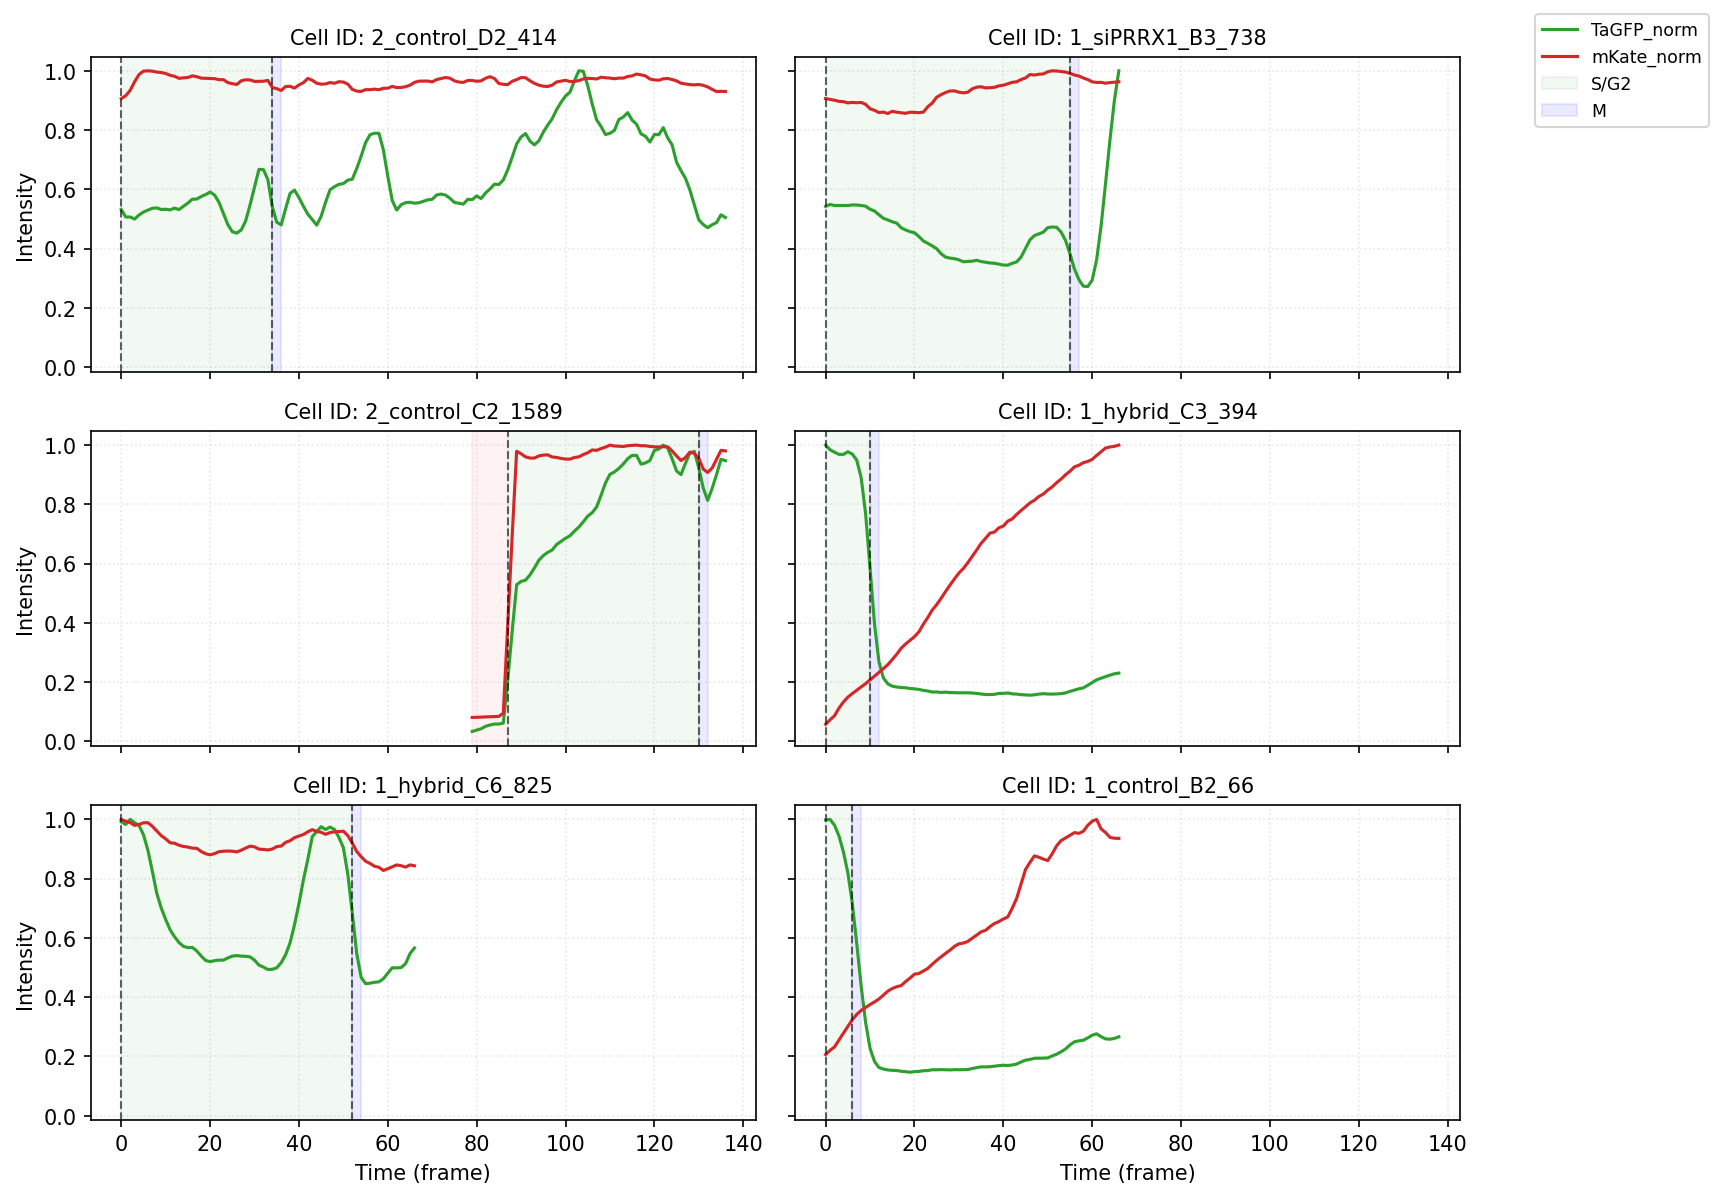

In [70]:
sampled_cells = np.random.choice(
    fdf["particle_id"].unique(), size=6, replace=False
)

fig, axes = plt.subplots(
    3, 2, figsize=(10, 8), sharex=True, sharey=True, dpi=150
)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    tmp = fdf[fdf["particle_id"] == cell_id].sort_values("frame")

    # 1. Plot the reporter lines
    ax.plot(
        tmp["frame"],
        tmp["TaGFP_norm"],
        label="TaGFP_norm",
        color="tab:green",
        lw=1.5,
    )
    ax.plot(
        tmp["frame"],
        tmp["mKate_norm"],
        label="mKate_norm",
        color="tab:red",
        lw=1.5,
    )

    # 2. Extract boundaries (Now directly matching the x-axis frames!)
    g1_s_boundary = tmp["rise_frame"].iloc[0]
    m_boundary = tmp["crash_frame"].iloc[0]
    track_start = tmp["frame"].min()
    track_end = tmp["frame"].max()

    # 3. Draw vertical line annotations
    if pd.notna(g1_s_boundary):
        ax.axvline(
            x=g1_s_boundary, color="black", linestyle="--", alpha=0.6, lw=1
        )
    if pd.notna(m_boundary):
        ax.axvline(
            x=m_boundary, color="black", linestyle="--", alpha=0.6, lw=1
        )

    # 4. Color-code the phase backgrounds
    # G1 Phase
    if pd.notna(g1_s_boundary) and g1_s_boundary > track_start:
        ax.axvspan(
            track_start,
            g1_s_boundary,
            color="red",
            alpha=0.05,
            label="G1" if idx == 0 else "",
        )

    # S/G2 Phase
    span_start = g1_s_boundary if pd.notna(g1_s_boundary) else track_start
    span_end = m_boundary if pd.notna(m_boundary) else track_end
    ax.axvspan(
        span_start,
        span_end,
        color="green",
        alpha=0.05,
        label="S/G2" if idx == 0 else "",
    )

    # M Phase
    if pd.notna(m_boundary):
        ax.axvspan(
            m_boundary,
            min(m_boundary + 2, track_end),
            color="blue",
            alpha=0.08,
            label="M" if idx == 0 else "",
        )

    # Layout styling
    ax.set_title(f"Cell ID: {cell_id}", fontsize=10)
    ax.grid(True, alpha=0.3, linestyle=":")

    if row == 2:
        ax.set_xlabel("Time (frame)")
    if col == 0:
        ax.set_ylabel("Intensity")

# Gather unique handles and labels for the global legend
handles, labels = [], []
for ax in axes.flat:
    h, l = ax.get_legend_handles_labels()
    for handle, label in zip(h, l):
        if label not in labels:
            handles.append(handle)
            labels.append(label)

fig.legend(
    handles,
    labels,
    loc="upper right",
    fontsize="small",
    bbox_to_anchor=(1.15, 1.0),
)

plt.tight_layout()
plt.show()

# Normalize reporters

In [38]:
# Global normalization for each reporter (by stage)
green_min = cdf.groupby("stage")["TaGFP_mean"].transform("min")
green_max = cdf.groupby("stage")["TaGFP_mean"].transform("max")

red_min = cdf.groupby("stage")["mKate_mean"].transform("min")
red_max = cdf.groupby("stage")["mKate_mean"].transform("max")

cy5_min = cdf.groupby("stage")["Cy5_mean"].transform("min")
cy5_max = cdf.groupby("stage")["Cy5_mean"].transform("max")

# 2. Perform the normalization using the stage-specific boundaries
cdf["TaGFP_norm"] = (cdf["TaGFP_mean"] - green_min) / (green_max - green_min)
cdf["mKate_norm"] = (cdf["mKate_mean"] - red_min) / (red_max - red_min)
cdf["Cy5_norm"] = (cdf["Cy5_mean"] - cy5_min) / (cy5_max - cy5_min)

print(cdf.shape)
cdf.head()

(868526, 26)


,frame,condition,scene,stage,particle,particle_id,time_shifted,filled_area,Cy5_mean,TaGFP_mean,...,is_interp,mkate_jump,tagfp_jump,max_cell_mkate_jump,max_cell_tagfp_jump,tracking_error,is_tracking_error,TaGFP_norm,mKate_norm,Cy5_norm
0,0,control,B2,1.0,0.0,1_control_B2_0,0.0,136.0,0.061765,0.408809,...,False,0.0,0.0,0.0,0.0,False,False,0.551797,0.972755,0.058795
1,1,control,B2,1.0,0.0,1_control_B2_0,1.0,143.0,0.149553,0.394926,...,False,0.0,0.0,0.0,0.0,False,False,0.533058,0.970810,0.176242
2,2,control,B2,1.0,0.0,1_control_B2_0,2.0,153.0,0.252953,0.375882,...,False,0.0,0.0,0.0,0.0,False,False,0.507353,0.954376,0.314575
3,3,control,B2,1.0,0.0,1_control_B2_0,3.0,156.0,0.374112,0.369431,...,False,0.0,0.0,0.0,0.0,False,False,0.498645,0.932787,0.476667
4,4,control,B2,1.0,0.0,1_control_B2_0,4.0,158.0,0.486338,0.368193,...,False,0.0,0.0,0.0,0.0,False,False,0.496974,0.932654,0.626808


# Drop noisy cells

In [ ]:
# %%time

# red = 'mKate_norm'
# green = 'TaGFP_norm'
# jump_thresh = 0.5
# max_allowed_jumps = 2

# df = test_df.copy()

# # --- Compute per-row differences, grouped by cell ---
# df['red_diff'] = df.groupby('particle_id')[red].diff().abs()
# df['green_diff'] = df.groupby('particle_id')[green].diff().abs()

# # --- Flag "big jumps" ---
# df['red_big_jump'] = df['red_diff'] > jump_thresh
# df['green_big_jump'] = df['green_diff'] > jump_thresh

# # --- Aggregate per-cell (particle_id): count of big jumps ---
# jump_counts = (
#     df.groupby('particle_id')[['red_big_jump', 'green_big_jump']].sum()
#     .rename(columns={'red_big_jump': 'red_big_jump_count', 'green_big_jump': 'green_big_jump_count'})
# )

# # --- Flag noisy cells at the cell (particle) level ---
# jump_counts['noisy'] = (jump_counts['red_big_jump_count'] > max_allowed_jumps) | \
#                        (jump_counts['green_big_jump_count'] > max_allowed_jumps)

# # --- Merge/noisy to df, then broadcast to all rows for each cell ---
# noisy_map = jump_counts['noisy']
# df['noisy'] = df['particle_id'].map(noisy_map)

# # Optional: Clean up helper cols
# df.drop(['red_diff', 'green_diff', 'red_big_jump', 'green_big_jump'], axis=1, inplace=True)
# df.head()

# Smooth signal

<timed exec>:18: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


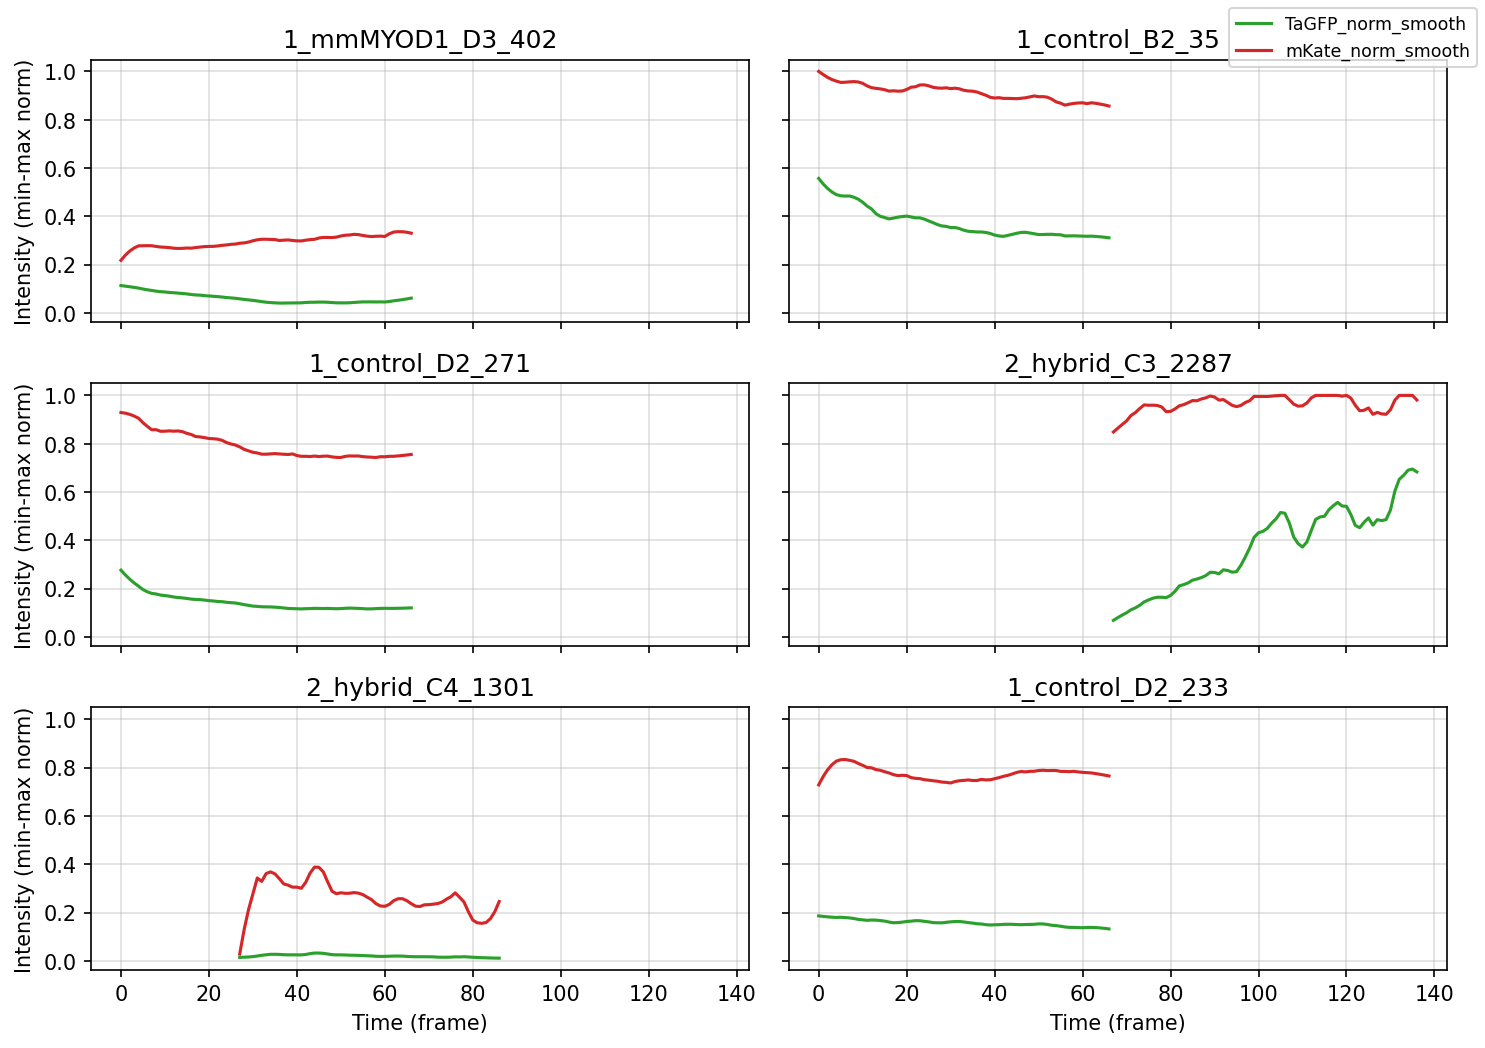

CPU times: user 25.2 s, sys: 359 ms, total: 25.6 s
Wall time: 26 s


In [39]:
%%time
def smooth_reporters_group(g, red_col='mKate_norm', green_col='TaGFP_norm', nuc_col='Cy5_norm', window_length=7, polyorder=2):
    g = g.copy()  # Don't modify in-place.
    n = len(g)
    # Must have enough points for filter
    good_len = min(n, window_length if n % 2 == 1 else window_length - 1)
    if good_len < 3:
        g[red_col + '_smooth'] = g[red_col]
        g[green_col + '_smooth'] = g[green_col]
        g[nuc_col + '_smooth'] = g[nuc_col]
    else:
        g = g.sort_values('frame')  # ensure frame order
        g[red_col + '_smooth'] = savgol_filter(g[red_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[green_col + '_smooth'] = savgol_filter(g[green_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
        g[nuc_col + '_smooth'] = savgol_filter(g[nuc_col], window_length=good_len, polyorder=min(polyorder, good_len-1)).clip(0, 1)
    return g

# Use groupby.apply for speed and auto-concatenation
cdf = cdf.groupby('particle_id', group_keys=False).apply(
    smooth_reporters_group, 
    red_col='mKate_norm', 
    green_col='TaGFP_norm', 
    nuc_col='Cy5_norm',
    window_length=9, 
    polyorder=2
)

sampled_cells = np.random.choice(cdf['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    tmp = cdf[cdf['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(tmp['frame'], tmp['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(tmp['frame'], tmp['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    # ax.plot(cdf['frame'], cdf['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()

# Full cycle cells

In [40]:
cdf = cdf.sort_values(["particle_id", "frame"]).copy()

# -------------------------------------------------------------------------
# 1. Compute Track-Specific Metrics for "Relative Changes"
# -------------------------------------------------------------------------
# Calculate the total range (max - min) observed within EACH individual track
track_ranges = cdf.groupby("particle_id")[
    ["mKate_norm_smooth", "TaGFP_norm_smooth"]
].transform(lambda x: x.max() - x.min())
cdf["track_red_range"] = track_ranges["mKate_norm_smooth"]
cdf["track_green_range"] = track_ranges["TaGFP_norm_smooth"]

# Calculate frame-to-frame changes (deltas) for each cell
cdf["red_delta"] = cdf.groupby("particle_id")["mKate_norm_smooth"].diff()
cdf["green_delta"] = cdf.groupby("particle_id")["TaGFP_norm_smooth"].diff()

# Define "relative" thresholds: e.g., a drop/rise must be at least 20% of that cell's entire dynamic range
cdf["is_big_green_drop"] = (
    cdf["green_delta"] <= -0.20 * cdf["track_green_range"]
)
cdf["is_red_rise"] = cdf["red_delta"] >= 0.15 * cdf["track_red_range"]

# Identify frame-by-frame who is dominant
cdf["red_above_green"] = cdf["mKate_norm_smooth"] > cdf["TaGFP_norm_smooth"]
cdf["green_above_red"] = cdf["TaGFP_norm_smooth"] > cdf["mKate_norm_smooth"]


# -------------------------------------------------------------------------
# 2. Aggregate Track Timeline Profiles
# -------------------------------------------------------------------------
# Group by cell to check if the required sequential events occurred anywhere in the track
cell_events = (
    cdf.groupby("particle_id")
    .agg(
        ever_red_above=("red_above_green", "any"),
        ever_green_above=("green_above_red", "any"),
        had_big_green_drop=("is_big_green_drop", "any"),
        had_red_rise=("is_red_rise", "any"),
        # Get the first frame where Green took over Red (G1 -> S switch)
        first_g1_s_frame=(
            "green_above_red",
            lambda x: x.idxmax() if x.any() else np.nan,
        ),
        # Get the first frame where a massive Mitotic Green crash happened
        first_m_drop_frame=(
            "is_big_green_drop",
            lambda x: x.idxmax() if x.any() else np.nan,
        ),
    )
    .reset_index()
)


# -------------------------------------------------------------------------
# 3. Apply Your Two Cycle Conditions
# -------------------------------------------------------------------------
# Path 1: Red > Green -> Switch (Green > Red) -> Big Drop in Green (Mitosis)
# Chronologically: The G1/S switch must happen BEFORE the M-phase green drop
condition_1 = (
    cell_events["ever_red_above"]
    & cell_events["ever_green_above"]
    & cell_events["had_big_green_drop"]
    & (cell_events["first_g1_s_frame"] < cell_events["first_m_drop_frame"])
)

# Path 2: Green > Red -> Mitotic Drop in Green + Simultaneous/Following Red Rise
# Note: Since 'first_m_drop_frame' tracks the row index, we can just ensure both events happen
condition_2 = (
    cell_events["ever_green_above"]
    & cell_events["had_big_green_drop"]
    & cell_events["had_red_rise"]
)

# Combine paths to flag full-cycle cells
cell_events["is_full_cycle"] = condition_1 | condition_2


# -------------------------------------------------------------------------
# 4. Filter the Main Dataframe
# -------------------------------------------------------------------------
# Map the flag back to the main dataframe
cdf = cdf.merge(cell_events[["particle_id", "is_full_cycle"]], on="particle_id")

# Create a filtered dataframe containing ONLY the full cycle cells
fdf = cdf[cdf["is_full_cycle"] == True].copy()

print(f"Total cells analyzed: {cdf['particle_id'].nunique()}")
print(f"Cells catching a full cycle: {fdf['particle_id'].nunique()}")

Total cells analyzed: 10061
Cells catching a full cycle: 745


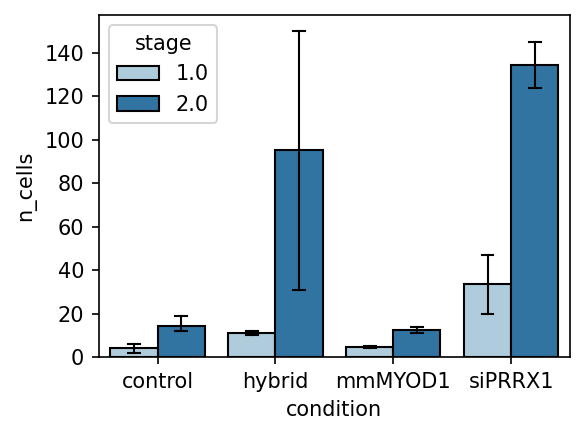

In [41]:
cell_counts = (
    fdf.groupby(['condition', 'scene', 'stage'])['particle_id']
    .nunique()
    .reset_index(name='n_cells')
)

plt.rcParams['figure.dpi'] = 150
fig, ax = plt.subplots(figsize=(4, 3))

sns.barplot(
    cell_counts,
    x='condition',
    y='n_cells',
    hue='stage',
    palette='Paired',
    ec='k',
    linewidth=1,
    capsize=0.2,
    err_kws={'color': 'k', 'lw': 1},
)

plt.tight_layout()
plt.show()

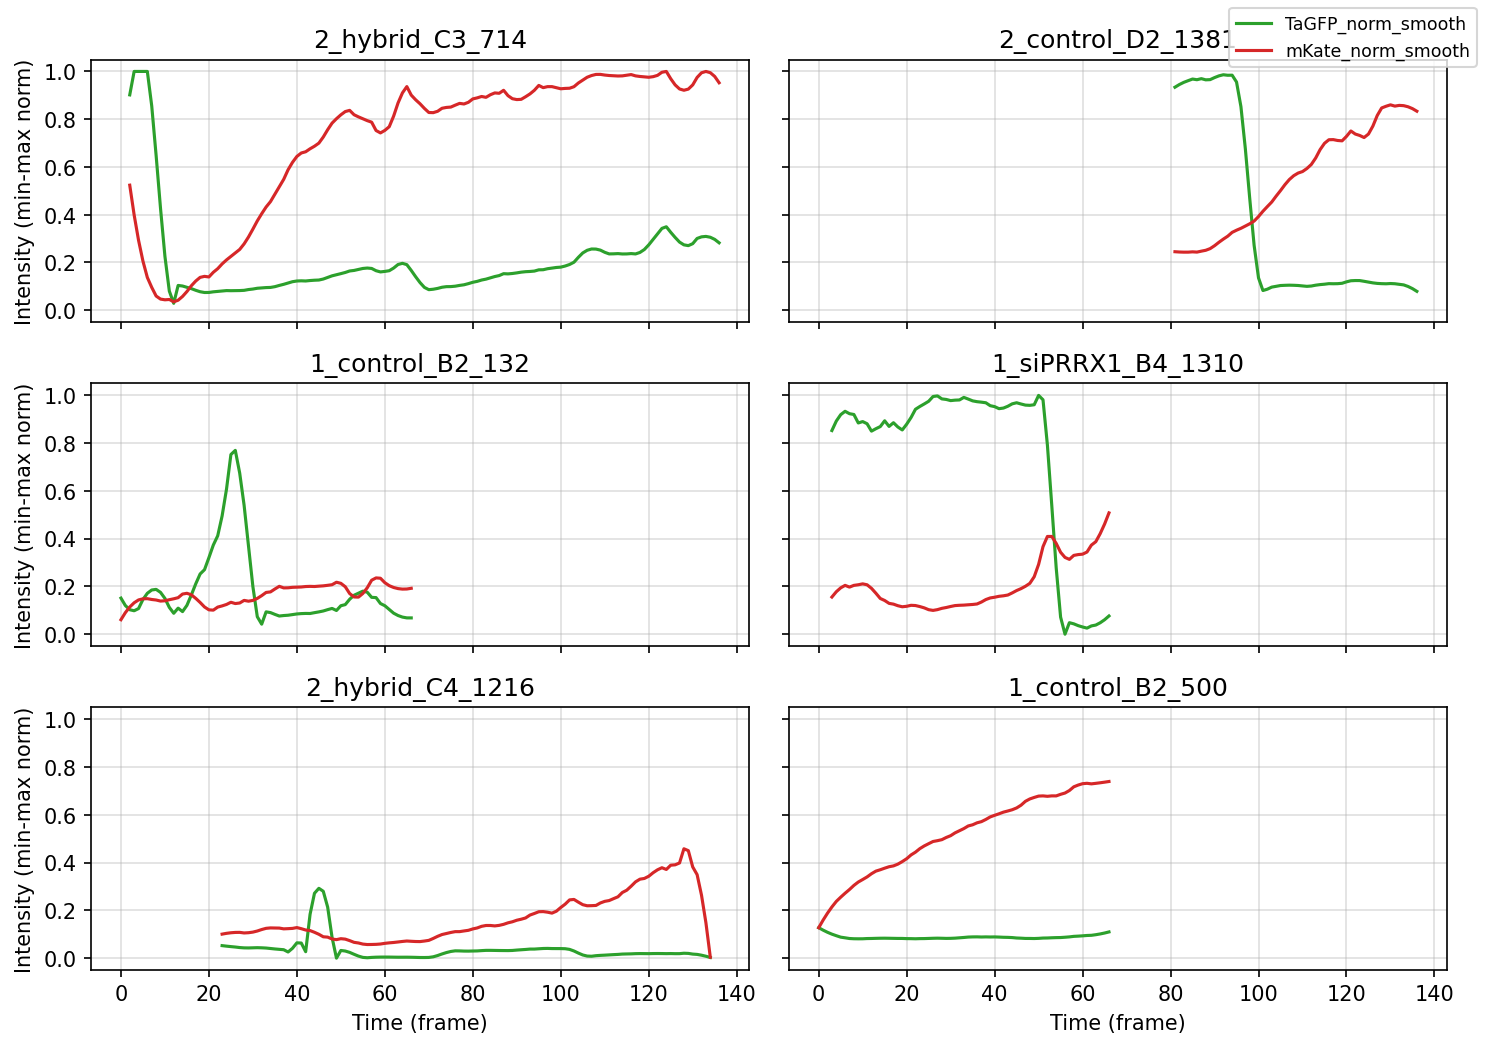

In [45]:
sampled_cells = np.random.choice(fdf['particle_id'].unique(), size=6, replace=False)

fig, axes = plt.subplots(3, 2, figsize=(10, 7), sharex=True, sharey=True, dpi=150)

for idx, cell_id in enumerate(sampled_cells):
    row, col = divmod(idx, 2)
    ax = axes[row, col]
    
    tmp = fdf[fdf['particle_id'] == cell_id].sort_values('frame')
    
    ax.plot(tmp['frame'], tmp['TaGFP_norm_smooth'], label='TaGFP_norm_smooth', color='tab:green')
    ax.plot(tmp['frame'], tmp['mKate_norm_smooth'], label='mKate_norm_smooth', color='tab:red')
    # ax.plot(tmp['frame'], tmp['Cy5_norm_smooth'], label='Cy5_norm_smooth', color='tab:blue')
    
    ax.set_title(f'{cell_id}')
    ax.grid(True, alpha=0.4)
    if row == 2: 
        ax.set_xlabel('Time (frame)')
    else:
        ax.set_xlabel('')
    if col == 0:
        ax.set_ylabel('Intensity (min-max norm)')
    else:
        ax.set_ylabel('')
    
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", fontsize='small')

plt.tight_layout()
plt.show()